In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("happiness_2020_report.csv")
print(df.shape)


(138, 10)


In [3]:
print(df.isnull().sum())

country              0
happiness_score      0
gdp_per_capita       0
social_support       0
health               0
freedom              0
generosity           0
government_trust     0
dystopia_residual    0
continent            0
dtype: int64


In [7]:
print(df.duplicated().sum())
print(df.columns)

0
Index(['country', 'happiness_score', 'gdp_per_capita', 'social_support',
       'health', 'freedom', 'generosity', 'government_trust',
       'dystopia_residual', 'continent'],
      dtype='str')


In [8]:
df.columns = df.columns.str.strip()
df

,country,happiness_score,gdp_per_capita,social_support,health,freedom,generosity,government_trust,dystopia_residual,continent
0,Finland,7.8087,1.285190,1.499526,0.961271,0.662317,0.159670,0.477857,2.762835,Europe
1,Denmark,7.6456,1.326949,1.503449,0.979333,0.665040,0.242793,0.495260,2.432741,Europe
2,Switzerland,7.5599,1.390774,1.472403,1.040533,0.628954,0.269056,0.407946,2.350267,Europe
3,Iceland,7.5045,1.326502,1.547567,1.000843,0.661981,0.362330,0.144541,2.460688,Europe
4,Norway,7.4880,1.424207,1.495173,1.008072,0.670201,0.287985,0.434101,2.168266,Europe
...,...,...,...,...,...,...,...,...,...,...
133,Botswana,3.4789,0.997549,1.085695,0.494102,0.509089,0.033407,0.101786,0.257241,Africa
134,Tanzania,3.4762,0.457163,0.872675,0.442678,0.509343,0.271541,0.203881,0.718963,Africa
135,Rwanda,3.3123,0.343243,0.522876,0.572383,0.604088,0.235705,0.485542,0.548445,Africa
136,Zimbabwe,3.2992,0.425564,1.047835,0.375038,0.377405,0.151349,0.080929,0.841031,Africa


In [9]:
numeric_columns = [
    'happiness_score',
    'gdp_per_capita',
    'social_support',
    'health',
    'freedom',
    'generosity',
    'government_trust',
    'dystopia_residual'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [10]:
print(df.describe())

       happiness_score  gdp_per_capita  social_support      health  \
count       138.000000      138.000000      138.000000  138.000000   
mean          5.550574        0.883662        1.170502    0.710566   
std           1.100890        0.363389        0.273588    0.236027   
min           2.566900        0.000000        0.352428    0.108744   
25%           4.774825        0.603273        1.003694    0.537377   
50%           5.550900        0.938030        1.219703    0.766572   
75%           6.298750        1.186638        1.393475    0.864669   
max           7.808700        1.536676        1.547567    1.137814   

          freedom  generosity  government_trust  dystopia_residual  
count  138.000000  138.000000        138.000000         138.000000  
mean     0.469280    0.187243          0.132014           1.997306  
std      0.139704    0.101467          0.115897           0.560026  
min      0.000000    0.000000          0.000000           0.257241  
25%      0.381600    0.1

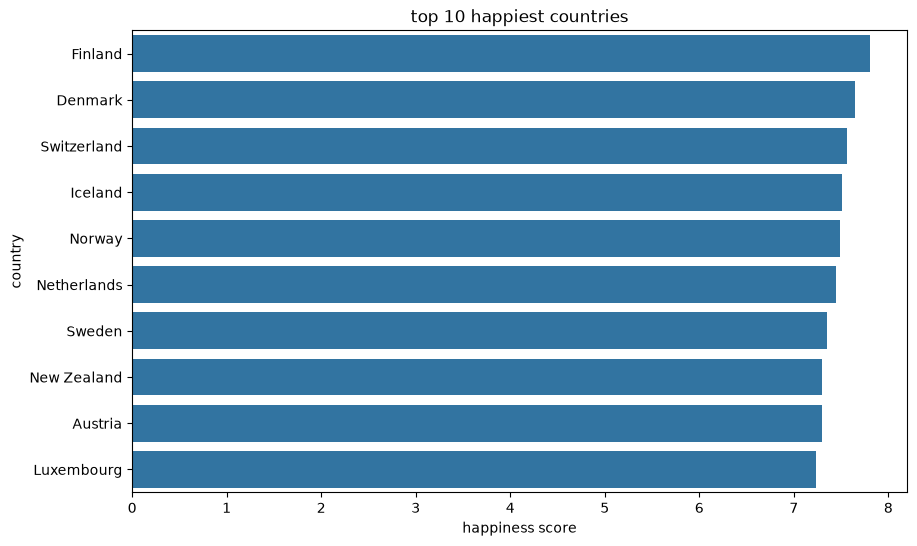

In [11]:
top10 = df.sort_values(
    'happiness_score',
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10,
    x='happiness_score',
    y='country'
)

plt.title("top 10 happiest countries")
plt.xlabel("happiness score")
plt.ylabel("country")
plt.show()

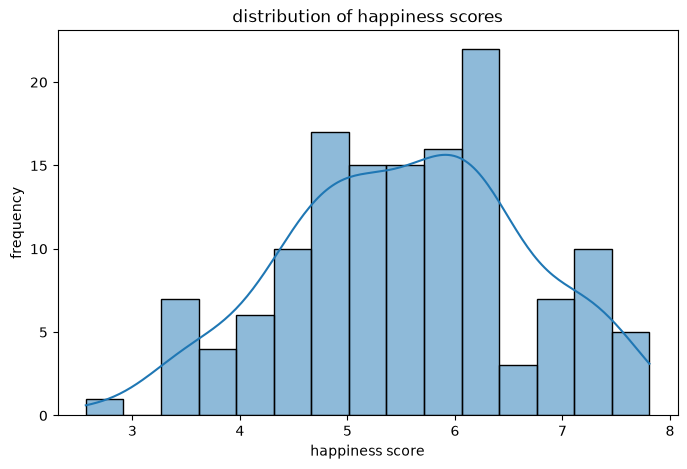

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df['happiness_score'],
    bins=15,
    kde=True
)

plt.title("distribution of happiness scores")
plt.xlabel("happiness score")
plt.ylabel("frequency")
plt.show()

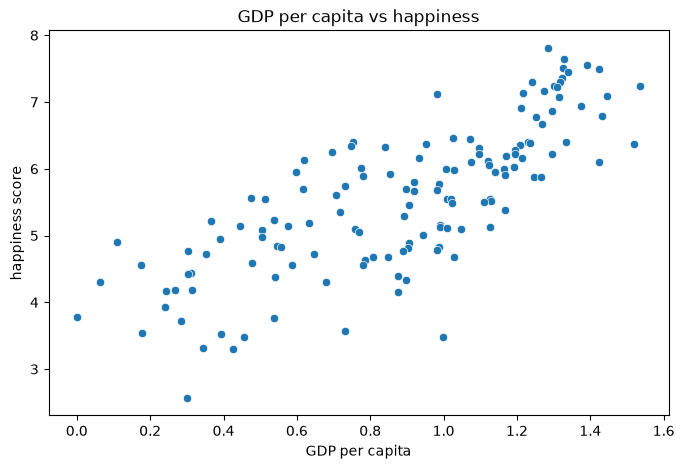

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='gdp_per_capita',
    y='happiness_score'
)

plt.title("GDP per capita vs happiness")
plt.xlabel("GDP per capita")
plt.ylabel("happiness score")
plt.show()

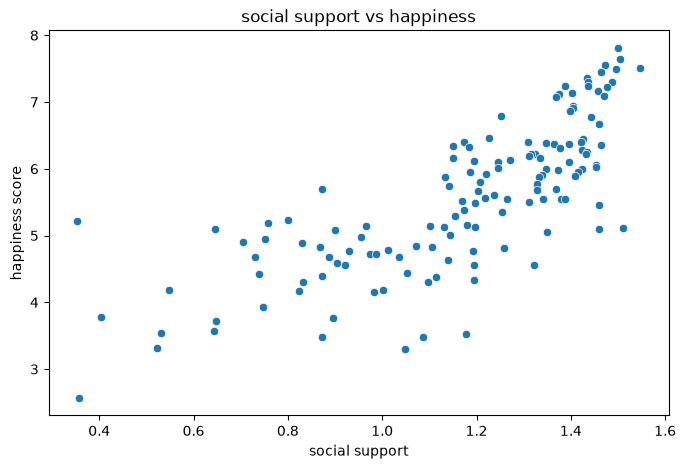

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='social_support',
    y='happiness_score'
)

plt.title("social support vs happiness")
plt.xlabel("social support")
plt.ylabel("happiness score")
plt.show()

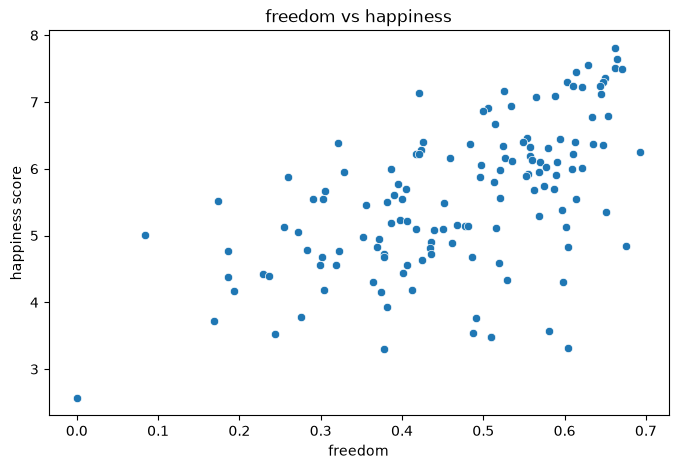

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='freedom',
    y='happiness_score'
)

plt.title("freedom vs happiness")
plt.xlabel("freedom")
plt.ylabel("happiness score")
plt.show()

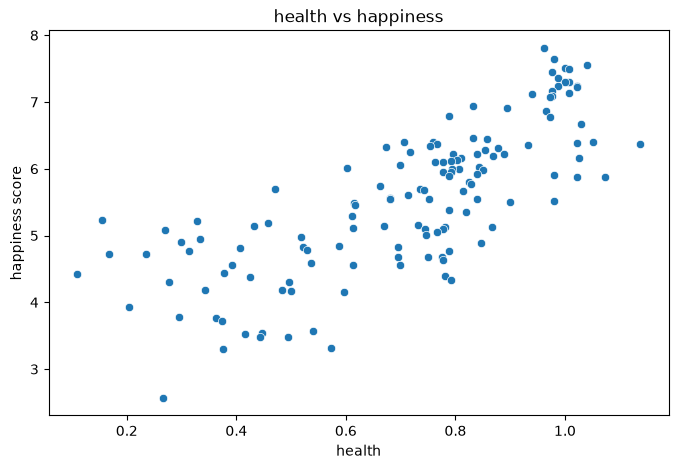

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='health',
    y='happiness_score'
)

plt.title("health vs happiness")
plt.xlabel("health")
plt.ylabel("happiness score")
plt.show()

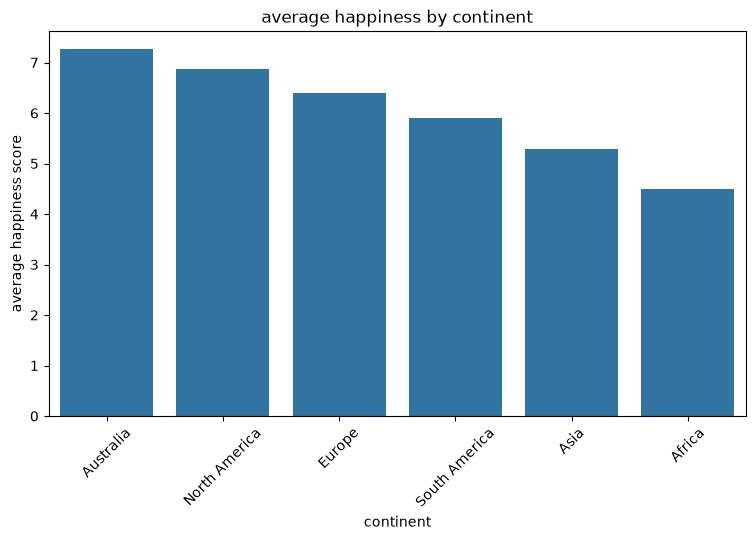

In [17]:
continent_happiness = (
    df.groupby('continent')['happiness_score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=continent_happiness.index,
    y=continent_happiness.values
)

plt.title("average happiness by continent")
plt.xlabel("continent")
plt.ylabel("average happiness score")
plt.xticks(rotation=45)
plt.show()

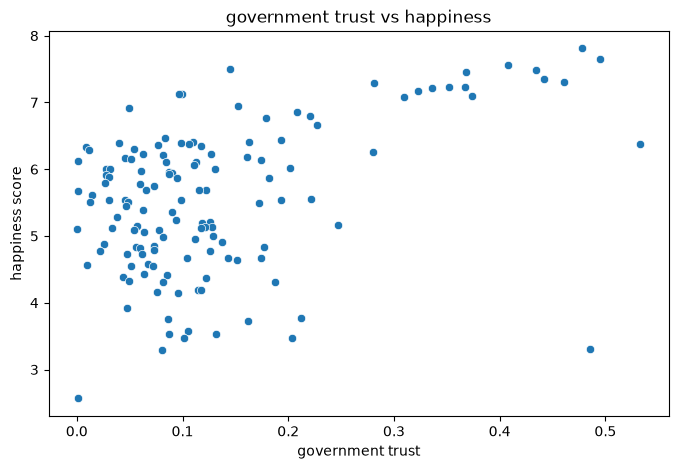

In [18]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='government_trust',
    y='happiness_score'
)

plt.title("government trust vs happiness")
plt.xlabel("government trust")
plt.ylabel("happiness score")
plt.show()

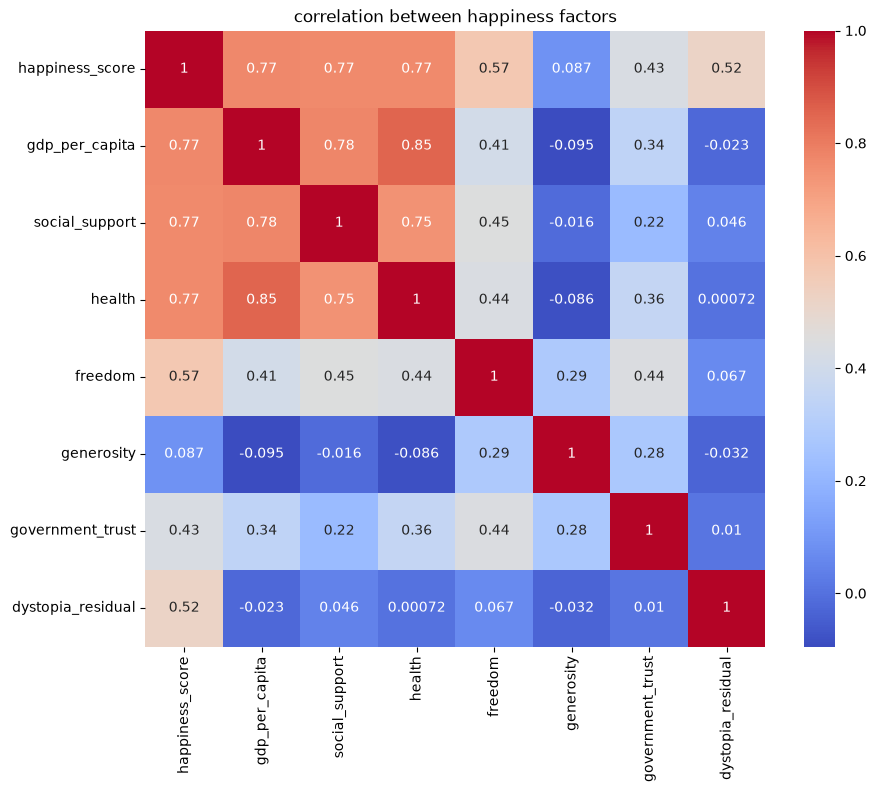

In [19]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("correlation between happiness factors")
plt.show()

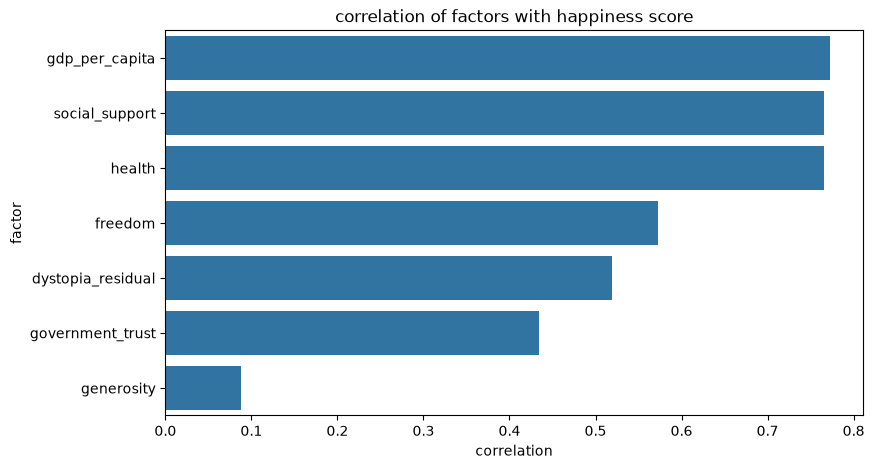

In [20]:
factors = [
    'gdp_per_capita',
    'social_support',
    'health',
    'freedom',
    'generosity',
    'government_trust',
    'dystopia_residual'
]

factor_correlation = df[factors + ['happiness_score']].corr()['happiness_score']
factor_correlation = factor_correlation.drop('happiness_score')
factor_correlation = factor_correlation.sort_values(ascending=False)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=factor_correlation.values,
    y=factor_correlation.index
)

plt.title("correlation of factors with happiness score")
plt.xlabel("correlation")
plt.ylabel("factor")
plt.show()